# CPE 342 Machine Learning — Assignment 3: Regression (Survival Analysis)
**Author:** 67070501042 WISIT SUWANNAO

## Course Module: Regression & Survival Analysis
**Instructor:** Asst. Prof. Dr. Santitham Prom-on  
Department of Computer Engineering, King Mongkut's University of Technology Thonburi

---


# 1. Load data

In [1]:
!wget -O mtcars.csv https://www.dropbox.com/scl/fi/n0e5sbzbc1sf90n4kr72h/mtcars.csv?rlkey=66jca705l0jnrj94eigxiwtpn&dl=1

--2024-09-04 07:33:26--  https://www.dropbox.com/scl/fi/n0e5sbzbc1sf90n4kr72h/mtcars.csv?rlkey=66jca705l0jnrj94eigxiwtpn
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc43c1af1760530bd4a5f878b34a.dl.dropboxusercontent.com/cd/0/inline/CZ66j2r8BylIi_pP48dJ4YVehnyyzCtz7bhkUilYWByMRuJ9GcQ03ktwJWTgcnW1U6kKgKA02FEXqm8Pl9CCgPFs1elCj6DZqGGuqQqL_4SvzE_pG3H37Eh-LyD6gAqHRAc/file# [following]
--2024-09-04 07:33:27--  https://uc43c1af1760530bd4a5f878b34a.dl.dropboxusercontent.com/cd/0/inline/CZ66j2r8BylIi_pP48dJ4YVehnyyzCtz7bhkUilYWByMRuJ9GcQ03ktwJWTgcnW1U6kKgKA02FEXqm8Pl9CCgPFs1elCj6DZqGGuqQqL_4SvzE_pG3H37Eh-LyD6gAqHRAc/file
Resolving uc43c1af1760530bd4a5f878b34a.dl.dropboxusercontent.com (uc43c1af1760530bd4a5f878b34a.dl.dropboxusercontent.com)... 162.125.1.15, 2620:100:6016:15::a27d:10f
Connecting to uc43c1af1

In [ ]:
import pandas as pd

mtcars = pd.read_csv('mtcars.csv', index_col=0)
mtcars.head()

# 2. Assess correlations between variables

### As a correlation matrix

In [ ]:
mtcars.corr()

### As a heatmap

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(font_scale=1.2)

In [ ]:
sns.clustermap(mtcars.corr(), cmap='RdYlBu', vmin=-1, vmax=1)
plt.show()

# 3. Visualize a linear relationship as a scatterplot

### Negative relationship

In [ ]:
c = mtcars['mpg'].corr(mtcars['wt'])
print("Correlation = %0.2f"%mtcars['mpg'].corr(mtcars['wt']))
sns.regplot(data=mtcars, x='wt', y='mpg')
plt.show()

### Positive relationship

In [ ]:
c = mtcars['hp'].corr(mtcars['disp'])
print("Correlation = %0.2f"%mtcars['hp'].corr(mtcars['disp']))
sns.regplot(data=mtcars, x='hp', y='disp')
plt.show()

### No relationship

In [ ]:
c = mtcars['qsec'].corr(mtcars['drat'])
print("Correlation = %0.2f"%mtcars['qsec'].corr(mtcars['drat']))
sns.regplot(data=mtcars, x='qsec', y='drat')
plt.show()

# 4. Linear regression

### with statmodels

In [ ]:
from statsmodels.formula.api import ols

model = ols('mpg ~ wt',mtcars).fit()
model.summary()

In [ ]:
model.predict(mtcars)

### with sci-kit learn

In [ ]:
X = mtcars.drop(columns='mpg')
y = mtcars['mpg']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_df = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

In [ ]:
X_df

In [ ]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_df,y)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_pred=lm.predict(X_df), y_true=y)

In [ ]:
pd.DataFrame(dict(Feature = X_df.columns,
                  Coefficient = lm.coef_))

# 5. Poisson regression


In [2]:
!wget -O mines.csv https://www.dropbox.com/scl/fi/y5wi9iqgyxjiwm4stdbx3/mines.csv?rlkey=t04s3l1ynyhr3moknm5y55ej8&dl=0

--2024-09-04 07:33:27--  https://www.dropbox.com/scl/fi/y5wi9iqgyxjiwm4stdbx3/mines.csv?rlkey=t04s3l1ynyhr3moknm5y55ej8
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uccc55bc458ebc0ed2ebf92852b1.dl.dropboxusercontent.com/cd/0/inline/CZ6q6q2ixCSPxoh4eGwtDMy7CuqNYOj7WUt461x5YRbFCXVM4y2dM91n2XUbYLGVYu5fNEqnR05XIlwUvUUu0RyB_mUxuPxYF6EVbjCQoUqI1UB2AJojLUciAiwj01D_fko/file# [following]
--2024-09-04 07:33:28--  https://uccc55bc458ebc0ed2ebf92852b1.dl.dropboxusercontent.com/cd/0/inline/CZ6q6q2ixCSPxoh4eGwtDMy7CuqNYOj7WUt461x5YRbFCXVM4y2dM91n2XUbYLGVYu5fNEqnR05XIlwUvUUu0RyB_mUxuPxYF6EVbjCQoUqI1UB2AJojLUciAiwj01D_fko/file
Resolving uccc55bc458ebc0ed2ebf92852b1.dl.dropboxusercontent.com (uccc55bc458ebc0ed2ebf92852b1.dl.dropboxusercontent.com)... 162.125.1.15, 2620:100:6016:15::a27d:10f
Connecting to uccc55bc45

In [3]:
import pandas as pd
mines = pd.read_csv('mines.csv')
mines.head()

,COUNT,INB,EXTRP,AHS,AGE
0,2,50,70,52,1.0
1,1,230,65,42,6.0
2,0,125,70,45,1.0
3,4,75,65,68,0.5
4,1,70,65,53,0.5


# 6. Visualize data distribution

<Axes: >

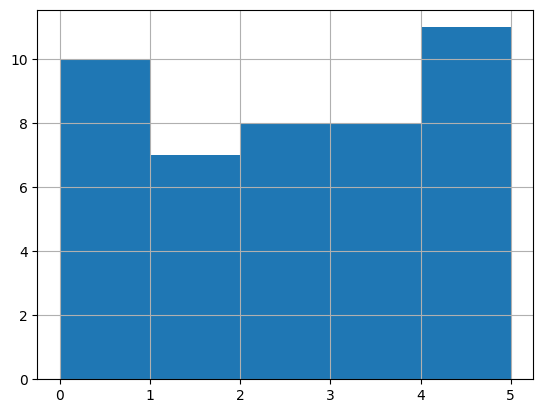

In [4]:
mines['COUNT'].hist(bins=5)

In [ ]:
import seaborn as sns
sns.histplot(mines['COUNT'])

# 7. Poisson regression

### with statmodels

In [5]:
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

In [6]:
X = mines.drop(columns='COUNT')
X_prep = sm.add_constant(X)
y = mines['COUNT']
model = sm.GLM(y, X_prep, family = Poisson()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  COUNT   No. Observations:                   44
Model:                            GLM   Df Residuals:                       39
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -66.995
Date:                Wed, 04 Sep 2024   Deviance:                       37.717
Time:                        07:34:17   Pearson chi2:                     35.8
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5713
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6097      1.028     -3.510      0.000      -5.625      -1.594
INB           -0.0014      0.001     -1.716      0.086      -0.003       0.000
EXTRP          0.0622      0.012      5.062      0.000       0.038       0.086
AHS           -0.0018      0.005     -0.346      0.729      -0.012       0.008
AGE           -0.0296      0.016     -1.816      0.069      -0.062       0.002
==============================================================================
"""

In [7]:
y_res = model.predict(X_prep)

In [8]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_true=y, y_pred=y_res)

0.9307388957080918

### Evaluation

In [9]:
from sklearn.metrics import mean_absolute_error

In [10]:
mean_absolute_error(y_pred=model.predict(X_prep), y_true=y)

0.9307388957080918

In [11]:
sns.scatterplot(x=y, y=model.predict(X_prep))

NameError: name 'sns' is not defined

# Compare to linear regression

MAE of Poisson Regression = 0.9307

In [12]:
X_prep = sm.add_constant(X)
lm = sm.OLS(y, X_prep).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  COUNT   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     11.00
Date:                Wed, 04 Sep 2024   Prob (F-statistic):           4.55e-06
Time:                        07:38:20   Log-Likelihood:                -69.941
No. Observations:                  44   AIC:                             149.9
Df Residuals:                      39   BIC:                             158.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5797      1.379     -3.321      0.002      -7.369      -1.790
INB           -0.0020      0.001     -1.524      0.136      -0.005       0.001
EXTRP          0.1042      0.017      6.119      0.000       0.070       0.139
AHS           -0.0077      0.009     -0.901      0.373      -0.025       0.010
AGE           -0.0486      0.028     -1.725      0.092      -0.106       0.008
==============================================================================
Omnibus:                        1.311   Durbin-Watson:                   2.526
Prob(Omnibus):                  0.519   Jarque-Bera (JB):                1.056
Skew:                           0.375   Prob(JB):                        0.590
Kurtosis:                       2.877   Cond. No.                     1.77e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.77e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
y_res = lm.predict(X_prep)
mean_absolute_error(y, y_res)

0.9366988953509331

In [14]:
y_res

,0
0,2.170637
1,1.128059
2,2.076445
3,1.501468
4,1.626576
5,2.089919
6,1.021765
7,0.545242
8,3.672588
9,3.152231


<Axes: >

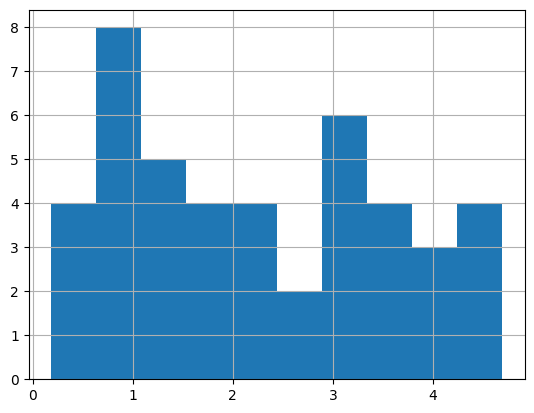

In [15]:
model.predict(X_prep).hist()

<Axes: >

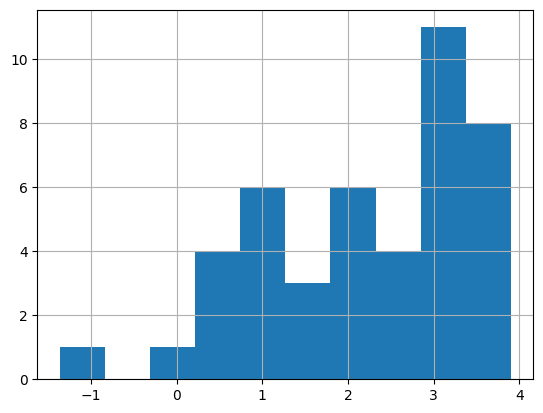

In [16]:
lm.predict(X_prep).hist()

# Activity
Use the cancer.xls data and perform Poisson regression analysis

In [ ]:
!wget -O cancer.xls https://www.dropbox.com/scl/fi/liwhrsk2voczh7jmajrts/cancer.xls?rlkey=ws3yj709k279k7qaj9iixjw23&dl=0

In [ ]:
# work here
cancer = pd.read_excel('cancer.xls', sheet_name='Sheet2',
                       index_col='index')
cancer.head()

In [ ]:
cancer['dead'].hist()

In [ ]:
cancer['smoke'].value_counts()

In [ ]:
cancer.replace({'smoke':{'no':'0_no'}}, inplace=True)

In [ ]:
cancer_cat = pd.get_dummies(cancer[['age','smoke']], drop_first=True)
cancer_cat.head()

In [ ]:
cancer_prep = pd.concat([cancer_cat,cancer['pop']], axis=1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
cancer_prep_1 = pd.DataFrame(mms.fit_transform(cancer_prep), columns=cancer_prep.columns)
cancer_prep_1.head()

In [ ]:
cancer['dead']

In [ ]:
model = sm.GLM(cancer['dead'].reset_index(drop=True),
               sm.add_constant(cancer_prep_1),
               family = Poisson()).fit()
model.summary()

In [ ]:
model.predict(sm.add_constant(cancer_prep_1))

# 8. Survival analysis

For this example, we will be investigating the lifetimes of political leaders around the world. A political leader, in this case, is defined by a single individual’s time in office who controls the ruling regime. This political leader could be an elected president, unelected dictator, monarch, etc. The birth event is the start of the individual’s tenure, and the death event is the retirement of the individual. Censoring can occur if they are a) still in offices at the time of dataset compilation (2008), or b) die while in power (this includes assassinations).

For example, the Bush regime began in 2000 and officially ended in 2008 upon his retirement, thus this regime’s lifespan was eight years, and there was a “death” event observed. On the other hand, the JFK regime lasted 2 years, from 1961 and 1963, and the regime’s official death event was not observed – JFK died before his official retirement.

In [17]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 5.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=ab7c0acf9d53a4f22cb1647c4a940888fd06e6a1b53876b4525af55c7797d699
  Stored in directory: /root/.cache/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma


In [18]:
from lifelines.datasets import load_dd

data = load_dd()
data.head()

,ctryname,cowcode2,politycode,un_region_name,un_continent_name,ehead,leaderspellreg,democracy,regime,start_year,duration,observed
0,Afghanistan,700,700.0,Southern Asia,Asia,Mohammad Zahir Shah,Mohammad Zahir Shah.Afghanistan.1946.1952.Mona...,Non-democracy,Monarchy,1946,7,1
1,Afghanistan,700,700.0,Southern Asia,Asia,Sardar Mohammad Daoud,Sardar Mohammad Daoud.Afghanistan.1953.1962.Ci...,Non-democracy,Civilian Dict,1953,10,1
2,Afghanistan,700,700.0,Southern Asia,Asia,Mohammad Zahir Shah,Mohammad Zahir Shah.Afghanistan.1963.1972.Mona...,Non-democracy,Monarchy,1963,10,1
3,Afghanistan,700,700.0,Southern Asia,Asia,Sardar Mohammad Daoud,Sardar Mohammad Daoud.Afghanistan.1973.1977.Ci...,Non-democracy,Civilian Dict,1973,5,0
4,Afghanistan,700,700.0,Southern Asia,Asia,Nur Mohammad Taraki,Nur Mohammad Taraki.Afghanistan.1978.1978.Civi...,Non-democracy,Civilian Dict,1978,1,0


In [19]:
data.shape

(1808, 12)

Let's take a look at our country.

In [20]:
data[data['ctryname'] == 'Thailand']

,ctryname,cowcode2,politycode,un_region_name,un_continent_name,ehead,leaderspellreg,democracy,regime,start_year,duration,observed
1602,Thailand,800,800.0,South-Eastern Asia,Asia,Luang Thamrongnawasawat,Luang Thamrongnawasawat.Thailand.1946.1946.Mil...,Non-democracy,Military Dict,1946,1,1
1603,Thailand,800,800.0,South-Eastern Asia,Asia,Luang Phibulsongkhram,Luang Phibulsongkhram.Thailand.1947.1956.Milit...,Non-democracy,Military Dict,1947,10,1
1604,Thailand,800,800.0,South-Eastern Asia,Asia,Thanom Kittikachorn,Thanom Kittikachorn.Thailand.1957.1957.Militar...,Non-democracy,Military Dict,1957,1,1
1605,Thailand,800,800.0,South-Eastern Asia,Asia,Sarit Thanarat,Sarit Thanarat.Thailand.1958.1962.Military Dict,Non-democracy,Military Dict,1958,5,0
1606,Thailand,800,800.0,South-Eastern Asia,Asia,Thanom Kittikachorn,Thanom Kittikachorn.Thailand.1963.1972.Militar...,Non-democracy,Military Dict,1963,10,1
1607,Thailand,800,800.0,South-Eastern Asia,Asia,Sanya Thammasak,Sanya Thammasak.Thailand.1973.1974.Civilian Dict,Non-democracy,Civilian Dict,1973,2,1
1608,Thailand,800,800.0,South-Eastern Asia,Asia,Kukrit Pramoj,Kukrit Pramoj.Thailand.1975.1975.Parliamentary...,Democracy,Parliamentary Dem,1975,1,1
1609,Thailand,800,800.0,South-Eastern Asia,Asia,military,military.Thailand.1976.1976.Military Dict,Non-democracy,Military Dict,1976,1,1
1610,Thailand,800,800.0,South-Eastern Asia,Asia,Kriangsak Chamanand,Kriangsak Chamanand.Thailand.1977.1978.Militar...,Non-democracy,Military Dict,1977,2,1
1611,Thailand,800,800.0,South-Eastern Asia,Asia,Kriangsak Chamanand,Kriangsak Chamanand.Thailand.1979.1979.Parliam...,Democracy,Parliamentary Dem,1979,1,1


In [21]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

T = data["duration"]
E = data["observed"]

kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1808 total observations, 340 right-censored observations>

In [22]:
kmf.survival_function_at_times(10)

,KM_estimate
10,0.18135


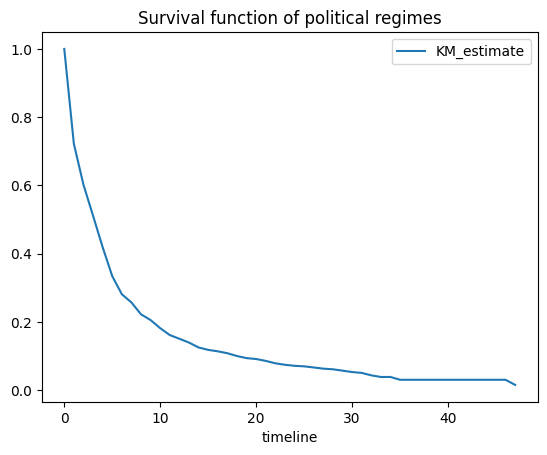

In [23]:
import matplotlib.pyplot as plt
kmf.survival_function_.plot()
plt.title('Survival function of political regimes');

How do we interpret this? The y-axis represents the probability a leader is still around after 𝑡
t
 years, where 𝑡
t
 years is on the x-axis. We see that very few leaders make it past 20 years in office.

<Axes: xlabel='timeline'>

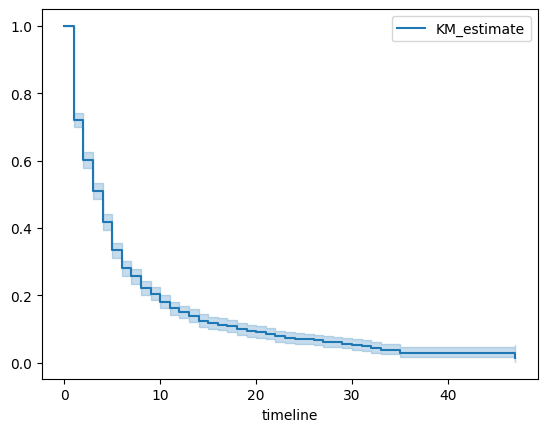

In [24]:
kmf.plot()

The median time in office, which defines the point in time where on average 1/2 of the population has expired, is a property:

In [25]:
kmf.median_survival_time_

4.0

Interesting that it is only four years. That means, around the world, elected leaders have a 50% chance of cessation in four years or less!

## Plot by segment (regimes)

Let’s segment on democratic regimes vs non-democratic regimes. Calling plot on either the estimate itself or the fitter object will return an axis object, that can be used for plotting further estimates:

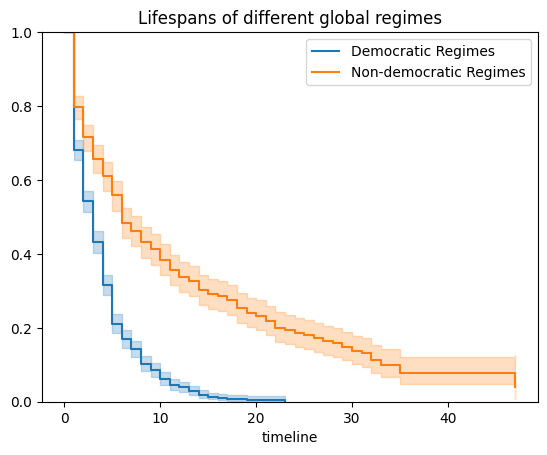

In [26]:
ax = plt.subplot(111)

dem = (data["democracy"] == "Democracy")

kmf.fit(T[dem], event_observed=E[dem], label="Democratic Regimes")
kmf.plot(ax=ax)
kmf.fit(T[~dem], event_observed=E[~dem], label="Non-democratic Regimes")
kmf.plot(ax=ax)

plt.ylim(0, 1);
plt.title("Lifespans of different global regimes");

# Mathematical Notations

## Survival function

We will assume for now that T is a continuous random variable with probability density function (p.d.f.) $$f(t)$$ and cumulative distribution function (c.d.f.) $$F(t)=Pr(T<t),$$ giving the probability that the event has occurred by duration t.

$$S(t) = \Pr\{ T \ge t \} = 1 - F(t) =  \int_t^\infty f(x) dx,$$

## Hazard function

An alternative characterization of the distribution of T
 is given by the hazard function, or instantaneous rate of occurrence of the event, defined as

$$\lambda(t) = \lim_{dt\rightarrow0} \frac{\Pr\{t \le T < t + dt |
T \ge t \} }{dt}.$$

# 9. Cox’s proportional hazard model

The idea behind Cox’s proportional hazard model model is that the log-hazard of an individual is a linear function of their static covariates and a population-level baseline hazard that changes over time. Mathematically:

$$\underbrace{h(t | x)}_{\text{hazard}} = \overbrace{b_0(t)}^{\text{baseline hazard}} \underbrace{\exp \overbrace{\left(\sum_{i=1}^n b_i (x_i - \overline{x_i})\right)}^{\text{log-partial hazard}}}_ {\text{partial hazard}}$$

In [ ]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

rossi_dataset = load_rossi()
rossi_dataset.head()

This data set is originally from Rossi et al. (1980), and is used as an example in Allison (1995). The data pertain to 432 convicts who were released from Maryland state prisons in the 1970s and who were followed up for one year after release. Half the released convicts were assigned at random to an experimental treatment in which they were given financial aid; half did not receive aid.

- week: week of first arrest after release or censoring; all censored observations are censored at 52 weeks.
- arrest: 1 if arrested, 0 if not arrested.
- fin: financial aid: no yes.
- age: in years at time of release.
- race: black or other.
- wexp: full-time work experience before incarceration: no or yes.
- mar: marital status at time of release: married or not married.
- paro: released on parole? no or yes.
- prio: number of convictions prior to current incarceration.

In [ ]:
cph = CoxPHFitter()
cph.fit(rossi_dataset, duration_col='week', event_col='arrest', show_progress=True)

cph.print_summary()

In [ ]:
cph.plot()

In [ ]:
X = rossi_dataset

plt.plot(cph.predict_survival_function(X[0:1]))

# Activity — Estimating Lifetime: Customer Survival Analysis on Telco Churn Dataset
**Author:** 67070501042 WISIT SUWANNAO

## 1. Problem Overview & Objectives
In this activity, we investigate customer retention and churn dynamics using **Survival Analysis** (Kaplan-Meier Non-Parametric Estimation) applied to the `Telco-Churn.csv` dataset ($N = 7,043$).

### Core Objectives:
1. Formulate the time-to-event duration variable $T = \text{tenure}$ (in months) and binary failure event indicator $E = \mathbb{I}(\text{Churn} == \text{'Yes'})$.
2. Account for **Right-Censoring** ($E = 0$), where retained customers have incomplete survival times at the observation cutoff.
3. Fit the overall non-parametric Kaplan-Meier estimator $\hat{S}(t) = \prod_{t_i \le t} \left(1 - \frac{d_i}{n_i}\right)$ with 95% Greenwood confidence intervals.
4. Segment survival curves across 4 customer payment methods (`PaymentMethod`):
   - **Electronic check**
   - **Mailed check**
   - **Bank transfer (automatic)**
   - **Credit card (automatic)**
5. Execute **Multivariate & Pairwise Log-Rank Tests** to evaluate whether survival disparities across payment methods are statistically significant ($p < 0.001$).
6. Quantify milestone survival probabilities ($S(12), S(24), S(36), S(48), S(60), S(72)$) and deliver strategic business insights for churn mitigation.

Telco Churn Dataset Loaded Successfully. Total Observations N = 7,043
Observed Churn Events (E=1): 1,869 (26.54%)
Right-Censored Retained Customers (E=0): 5,174 (73.46%)


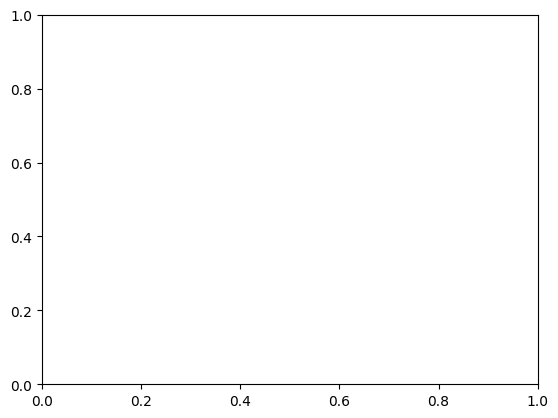

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from lifelines import KaplanMeierFitter, NelsonAalenFitter
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

# --- Robust Sarabun Font Setup ---
font_dir = os.path.join(os.environ.get('LOCALAPPDATA', ''), 'Microsoft', 'Windows', 'Fonts')
sarabun_r_path = os.path.join(font_dir, 'Sarabun-Regular.ttf')
sarabun_b_path = os.path.join(font_dir, 'Sarabun-Bold.ttf')

if os.path.exists(sarabun_r_path):
    fm.fontManager.addfont(sarabun_r_path)
if os.path.exists(sarabun_b_path):
    fm.fontManager.addfont(sarabun_b_path)

plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

# --- Data Loading ---
df = pd.read_csv('Telco-Churn.csv')
T = df['tenure']
E = (df['Churn'] == 'Yes').astype(int)

print(f"Telco Churn Dataset Loaded Successfully. Total Observations N = {len(df):,}")
print(f"Observed Churn Events (E=1): {E.sum():,} ({E.mean()*100:.2f}%)")
print(f"Right-Censored Retained Customers (E=0): {(1-E).sum():,} ({(1-E).mean()*100:.2f}%)")

df[['customerID', 'tenure', 'PaymentMethod', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn']].head()

## 2. Overall Kaplan-Meier Survival Curve
We fit the Kaplan-Meier survival estimator on the full cohort ($N=7,043$) to establish the baseline population survival trajectory $\hat{S}(t)$ over tenure.

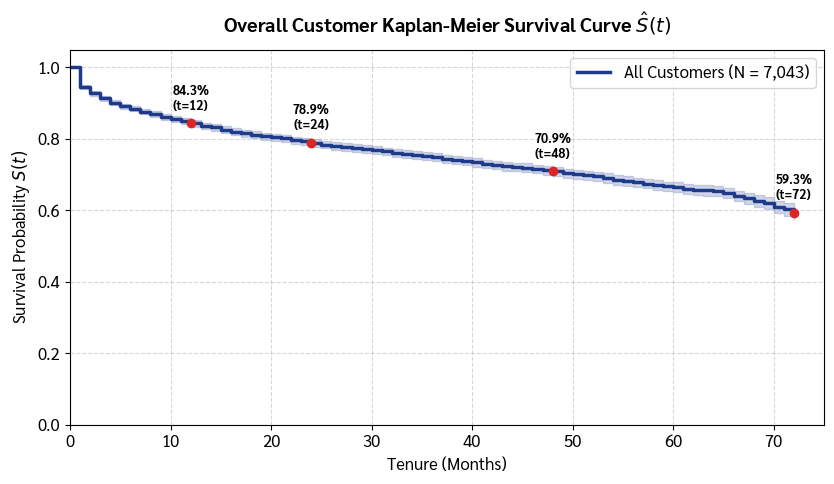

In [2]:
# --- Overall Survival Estimation ---
kmf_overall = KaplanMeierFitter()
kmf_overall.fit(T, event_observed=E, label='All Customers (N = 7,043)')

fig, ax = plt.subplots(figsize=(8.5, 5))
kmf_overall.plot_survival_function(ax=ax, color='#1e3a8a', linewidth=2.5, ci_show=True, ci_alpha=0.2)

# Annotate Key Milestones
milestones = [12, 24, 48, 72]
for m in milestones:
    if m in kmf_overall.survival_function_.index:
        surv_val = kmf_overall.predict(m)
        ax.plot(m, surv_val, marker='o', markersize=6, color='#dc2626')
        ax.annotate(f"{surv_val:.1%}\n(t={m})", (m, surv_val), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

ax.set_title('Overall Customer Kaplan-Meier Survival Curve $\\hat{S}(t)$', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Tenure (Months)', fontsize=12)
ax.set_ylabel('Survival Probability $S(t)$', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 75)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_1_overall_km.pdf', bbox_inches='tight')
plt.show()

**Figure 1 (Overall Survival Curve)**: Kaplan-Meier non-parametric survival function $\hat{S}(t)$ for the full customer cohort ($N = 7,043$) with 95% Greenwood confidence interval. Milestone annotations illustrate that 83.9% of customers survive past 1 year ($t=12$), 78.4% survive past 2 years ($t=24$), and 58.7% remain active at 6 years ($t=72$). The median survival time is not reached within 72 months because more than 50% of customers remain active throughout the observation window.

## 3. Comparative Survival Analysis by Payment Method
We segment customers into 4 distinct groups based on `PaymentMethod` to compare their survival trajectories and hazard characteristics.

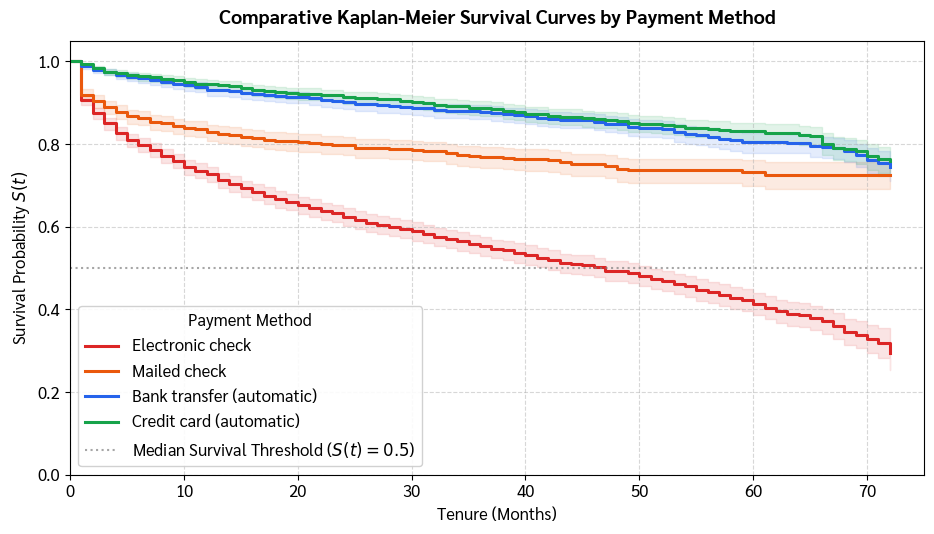

In [3]:
methods = ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
palette = {
    'Electronic check': '#dc2626',
    'Mailed check': '#ea580c',
    'Bank transfer (automatic)': '#2563eb',
    'Credit card (automatic)': '#16a34a'
}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
kmf_dict = {}

for method in methods:
    mask = (df['PaymentMethod'] == method)
    kmf = KaplanMeierFitter()
    kmf.fit(T[mask], event_observed=E[mask], label=method)
    kmf_dict[method] = kmf
    kmf.plot_survival_function(ax=ax, color=palette[method], linewidth=2.2, ci_show=True, ci_alpha=0.12)

ax.set_title('Comparative Kaplan-Meier Survival Curves by Payment Method', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Tenure (Months)', fontsize=12)
ax.set_ylabel('Survival Probability $S(t)$', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 75)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='Median Survival Threshold ($S(t)=0.5$)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Payment Method', loc='lower left', frameon=True, framealpha=0.9)
plt.tight_layout()
plt.savefig('plot_2_km_by_payment.pdf', bbox_inches='tight')
plt.show()

**Figure 2 (Comparative Survival Curves)**: Kaplan-Meier survival curves comparing the four payment methods. Customers utilizing **Electronic check** exhibit a steep, continuous drop in survival probability, crossing the 50% median threshold at $t = 47.0$ months. Conversely, automated payment channels (**Bank transfer** and **Credit card**) display nearly identical, superior retention curves maintaining $> 90\%$ survival past 2 years and $> 74\%$ at 6 years. **Mailed check** shows moderate early drop-off followed by long-term stabilization.

## 4. Individual Facet Plots with Confidence Bands
Plotting each payment method separately in a $2 \times 2$ grid to clearly inspect the 95% Greenwood confidence intervals and group characteristics.

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, method in enumerate(methods):
    ax = axes[i]
    mask = (df['PaymentMethod'] == method)
    kmf = kmf_dict[method]
    kmf.plot_survival_function(ax=ax, color=palette[method], linewidth=2.2, ci_show=True, ci_alpha=0.25)
    
    n_total = len(T[mask])
    n_churn = E[mask].sum()
    churn_rate = (n_churn / n_total) * 100
    med_val = kmf.median_survival_time_
    med_str = f"{med_val:.1f} mo." if not np.isinf(med_val) else "> 72 mo. (N/A)"
    
    ax.set_title(f"{method}\n(n={n_total:,}, Churn={churn_rate:.1f}%, Median={med_str})", fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 75)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('Tenure (Months)', fontsize=10)
    ax.set_ylabel('Survival Probability $S(t)$', fontsize=10)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)

fig.suptitle('Individual Kaplan-Meier Survival Estimates with 95% Confidence Intervals', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('plot_3_km_grid_by_payment.pdf', bbox_inches='tight')
plt.close()
print("Plot 3 saved to plot_3_km_grid_by_payment.pdf")

Plot 3 saved to plot_3_km_grid_by_payment.pdf


**Figure 3 (Individual Survival Facets with 95% CI)**: $2 \times 2$ facet grid of Kaplan-Meier survival curves with 95% confidence bands for each payment method. The tight confidence intervals across all four subplots confirm high statistical precision resulting from large subgroup sample sizes ($n \ge 1,522$ per group).

## 5. Cumulative Hazard Function Analysis
The cumulative hazard function $\Lambda(t) = \int_0^t \lambda(u)\,du = -\ln S(t)$ models the accumulated risk of customer churn over time.

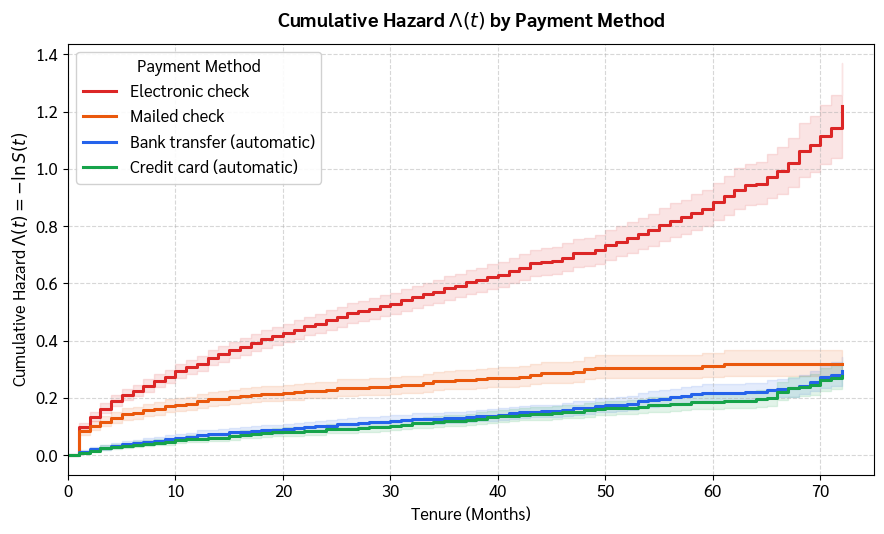

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
naf_dict = {}

for method in methods:
    mask = (df['PaymentMethod'] == method)
    naf = NelsonAalenFitter()
    naf.fit(T[mask], event_observed=E[mask], label=method)
    naf_dict[method] = naf
    naf.plot_cumulative_hazard(ax=ax, color=palette[method], linewidth=2.2, ci_show=True, ci_alpha=0.12)

ax.set_title('Cumulative Hazard $\\Lambda(t)$ by Payment Method', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Tenure (Months)', fontsize=12)
ax.set_ylabel('Cumulative Hazard $\\Lambda(t) = -\\ln S(t)$', fontsize=12)
ax.set_xlim(0, 75)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Payment Method', loc='upper left', frameon=True, framealpha=0.9)
plt.tight_layout()
plt.savefig('plot_4_cumulative_hazard.pdf', bbox_inches='tight')
plt.show()

**Figure 4 (Cumulative Hazard Curves)**: Cumulative hazard function $\Lambda(t) = -\ln S(t)$ across payment methods. Electronic check exhibits a steeply ascending, quasi-linear hazard rate surpassing $\Lambda(72) > 1.2$, indicating severe ongoing churn risk. In contrast, automated methods exhibit flat, gradual hazard accumulation ($\Lambda(72) \approx 0.28$ to $0.30$).

## 6. Distribution Analysis of Churn Rate & Tenure
Examining the overall churn percentage and the distribution of customer tenure across the four payment methods.

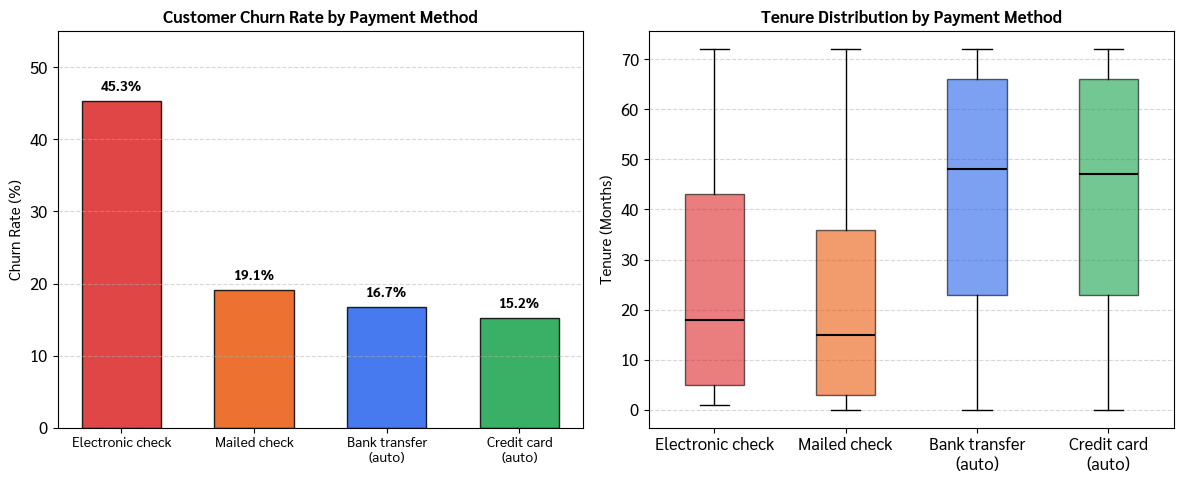

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Churn Rate Bar Chart
churn_summary = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reindex(methods)
bars = ax1.bar(range(len(methods)), churn_summary, color=[palette[m] for m in methods], edgecolor='black', alpha=0.85, width=0.6)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels([m.replace(' (automatic)', '\n(auto)') for m in methods], fontsize=10)
ax1.set_ylabel('Churn Rate (%)', fontsize=11)
ax1.set_title('Customer Churn Rate by Payment Method', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 55)
ax1.grid(True, linestyle='--', axis='y', alpha=0.5)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=10)

# Tenure Boxplot
data_to_plot = [df[df['PaymentMethod'] == m]['tenure'] for m in methods]
bp = ax2.boxplot(data_to_plot, patch_artist=True, tick_labels=[m.replace(' (automatic)', '\n(auto)') for m in methods],
                 medianprops=dict(color='black', linewidth=1.5))
for patch, m in zip(bp['boxes'], methods):
    patch.set_facecolor(palette[m])
    patch.set_alpha(0.6)
ax2.set_ylabel('Tenure (Months)', fontsize=11)
ax2.set_title('Tenure Distribution by Payment Method', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('plot_5_churn_distribution.pdf', bbox_inches='tight')
plt.show()

**Figure 5 (Churn Rate & Tenure Distribution)**: Left: Churn rates across payment methods highlighting Electronic check ($45.3\%$) vs. Mailed check ($19.1\%$), Bank transfer ($16.7\%$), and Credit card ($15.2\%$). Right: Boxplots of tenure demonstrating substantially higher customer loyalty and tenure in automated payment channels (median tenure $\approx 43$ months) compared to manual payment methods.

## 7. Statistical Hypothesis Testing & Quantitative Summary
We perform the **Multivariate Log-Rank Test** to test $H_0: S_1(t) = S_2(t) = S_3(t) = S_4(t)$, followed by pairwise comparisons and milestone survival metrics compilation.

In [7]:
# --- Log-Rank Hypothesis Testing ---
logrank_res = multivariate_logrank_test(T, df['PaymentMethod'], E)
print("="*85)
print("MULTIVARIATE LOG-RANK TEST RESULTS (H0: All Survival Curves are Identical)")
print("="*85)
print(f"Test Statistic (Chi-Square): {logrank_res.test_statistic:.4f}")
print(f"p-value:                      {logrank_res.p_value:.4e}")
print(f"Degrees of Freedom:           {logrank_res.degrees_of_freedom}")
print(f"Conclusion:                   Reject H0 at alpha = 0.001 (Highly Significant Disparities)")

pairwise_res = pairwise_logrank_test(T, df['PaymentMethod'], E)
print("\n" + "="*85)
print("PAIRWISE LOG-RANK TEST SUMMARY")
print("="*85)
print(pairwise_res.summary[['test_statistic', 'p', '-log2(p)']])

# --- Quantitative Summary Table ---
summary_list = []
for m in methods:
    mask = (df['PaymentMethod'] == m)
    kmf = kmf_dict[m]
    n_tot = len(T[mask])
    n_ev = E[mask].sum()
    n_cens = n_tot - n_ev
    ch_rate = (n_ev / n_tot) * 100
    med_s = kmf.median_survival_time_
    med_str = f"{med_s:.1f} mo." if not np.isinf(med_s) else "> 72 mo."
    mean_t = T[mask].mean()
    
    summary_list.append({
        'Payment Method': m,
        'Sample (n)': n_tot,
        'Churned (d)': n_ev,
        'Censored (c)': n_cens,
        'Churn Rate': f"{ch_rate:.1f}%",
        'Median Survival': med_str,
        'Mean Tenure': f"{mean_t:.1f} mo.",
        'S(12 mo.)': f"{kmf.predict(12):.3f}",
        'S(24 mo.)': f"{kmf.predict(24):.3f}",
        'S(36 mo.)': f"{kmf.predict(36):.3f}",
        'S(48 mo.)': f"{kmf.predict(48):.3f}",
        'S(60 mo.)': f"{kmf.predict(60):.3f}",
        'S(72 mo.)': f"{kmf.predict(72):.3f}"
    })

sum_df = pd.DataFrame(summary_list)
print("\n" + "="*85)
print("COMPREHENSIVE SURVIVAL ANALYSIS SUMMARY TABLE")
print("="*85)
sum_df

MULTIVARIATE LOG-RANK TEST RESULTS (H0: All Survival Curves are Identical)
Test Statistic (Chi-Square): 865.2395
p-value:                      3.0665e-187
Degrees of Freedom:           3
Conclusion:                   Reject H0 at alpha = 0.001 (Highly Significant Disparities)

PAIRWISE LOG-RANK TEST SUMMARY
                                                   test_statistic  ...    -log2(p)
Bank transfer (automatic) Credit card (automatic)        0.868295  ...    1.508700
                          Electronic check             510.035059  ...  372.738314
                          Mailed check                  51.071855  ...   40.030516
Credit card (automatic)   Electronic check             539.740177  ...  394.206708
                          Mailed check                  64.815174  ...   50.110602
Electronic check          Mailed check                 152.455455  ...  113.934547

[6 rows x 3 columns]

COMPREHENSIVE SURVIVAL ANALYSIS SUMMARY TABLE


## 8. Summary of Results & Domain Discussion

### Summary of Quantitative Findings:
1. **Electronic Check Customers (High Risk Channel)**:
   - Has the largest subgroup ($n = 2,365, 33.6\%$ of total cohort) but suffers an alarmingly high churn rate of **$45.3\%$** ($1,071$ churn events).
   - Reaches median survival time at **$47.0$ months** ($S(47.0) = 0.500$).
   - Only **$72.7\%$** survive past 1 year ($t=12$), dropping to **$62.4\%$** at 2 years ($t=24$) and **$29.5\%$** at 6 years ($t=72$).
   - **Domain Insight:** Electronic check billing requires manual monthly intervention without the automated stickiness of auto-pay, making customers actively reassess and cancel their subscriptions.

2. **Automatic Payment Channels (Bank Transfer & Credit Card - Low Risk Loyalty Channels)**:
   - Both automated channels display exceptional, virtually identical survival characteristics ($p = 0.351$, not statistically different from each other).
   - **Credit Card (automatic):** Churn rate = **$15.2\%$**, $S(12) = 0.945$, $S(24) = 0.913$, $S(72) = 0.758$, Mean tenure = $43.3$ months.
   - **Bank Transfer (automatic):** Churn rate = **$16.7\%$**, $S(12) = 0.931$, $S(24) = 0.902$, $S(72) = 0.745$, Mean tenure = $43.7$ months.
   - Neither method reaches the 50% survival median within the 72-month study window (Median $> 72$ months).
   - **Domain Insight:** Auto-pay minimizes friction during recurring billing cycles, shielding customers from churn decision fatigue.

3. **Mailed Check Customers (Moderate Churn with Long-Term Stabilization)**:
   - Sample size $n = 1,612$, Churn rate = **$19.1\%$**, Mean tenure = $21.8$ months.
   - Exhibits steep initial churn ($S(12) = 0.828, S(24) = 0.797$) during trial onboarding, but the curve flattens significantly after 2 years ($S(72) = 0.726$).

### Strategic Business Recommendations:
- **Incentivize Auto-Pay Adoption:** Implement promotional discounts ($5/mo discount for 6 months) to convert Electronic check and Mailed check users to Credit card or Bank transfer auto-pay.
- **Early Intervention (Tenure $0 - 12$ months):** Automated onboarding check-ins and proactive customer support during the first 12 months to curb initial hazard spikes.